In [ ]:
!pip install PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.1 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
import nltk
from nltk.tokenize import word_tokenize

# Download NLTK punkt for tokenization (run once)
nltk.download('punkt')
nltk.download('punkt_tab') # Add this line to fix the LookupError

def compute_sentiment_indicators(documents, pos_dict, neg_dict):
    """
    Simulates the NLP step: Calculates sentiment scores for text documents.
    In the paper, this is done around specific economic concepts (e.g., inflation, employment).
    """
    sentiments = []

    for doc in documents:
        tokens = word_tokenize(doc.lower())
        total_words = len(tokens)

        if total_words == 0:
            sentiments.append(0)
            continue

        pos_count = sum(1 for word in tokens if word in pos_dict)
        neg_count = sum(1 for word in tokens if word in neg_dict)

        # Net sentiment scaled by document length
        net_sentiment = (pos_count - neg_count) / total_words
        sentiments.append(net_sentiment)

    return np.array(sentiments)

def identify_monetary_policy_shocks(delta_ffr, numerical_forecasts, sentiment_matrix):
    """
    Replicates the Aruoba & Drechsel (2024/2025) Ridge regression methodology.
    """
    # 1. Combine numerical forecasts and text-based sentiment indicators
    X_linear = np.hstack([numerical_forecasts, sentiment_matrix])

    # 2. Introduce Nonlinearities (Quadratic terms)
    # The paper explicitly adds squared terms to capture nonlinear policy rules
    poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
    X_poly = poly.fit_transform(X_linear)

    # 3. Scale the features (Crucial for Ridge Regression)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_poly)

    # 4. Fit Ridge Regression with Cross-Validation
    # The paper selects the regularization parameter (lambda/alpha) to optimize fit
    # alphas represent different penalty strengths for the Ridge regression
    ridge = RidgeCV(alphas=np.logspace(-3, 4, 100), cv=5, scoring='neg_mean_squared_error')
    ridge.fit(X_scaled, delta_ffr)

    # 5. Predict systematic policy changes and extract exogenous shocks (residuals)
    systematic_policy = ridge.predict(X_scaled)
    ad_shocks = delta_ffr - systematic_policy

    print(f"Optimal Ridge Penalty (Alpha): {ridge.alpha_:.4f}")
    print(f"R-squared: {ridge.score(X_scaled, delta_ffr):.4f}")

    return systematic_policy, ad_shocks

# ==========================================
# Example Usage with Synthetic Data
# ==========================================
if __name__ == "__main__":
    np.random.seed(42)
    n_meetings = 200 # e.g., 200 FOMC meetings

    # 1. Simulate change in Target Federal Funds Rate (Target Variable)
    delta_ffr = np.random.normal(0, 0.25, n_meetings)

    # 2. Simulate Numerical Forecasts (e.g., Greenbook forecasts for GDP, Inflation, Unemployment)
    numerical_forecasts = np.random.normal(0, 1, (n_meetings, 3))

    # 3. Simulate NLP / Text Data (Fed Staff Documents)
    # In reality, this would be the parsed text from Greenbooks/Tealbooks
    sample_texts = [
        "Inflation is rising rapidly, growth is strong.",
        "The economy is slowing down, recession risks are high.",
        "Employment remains stable, but credit conditions are tightening."
    ] * (n_meetings // 3 + 1)
    sample_texts = sample_texts[:n_meetings]

    # Simple Loughran-McDonald style financial dictionaries
    positive_words = {'strong', 'stable', 'growth', 'expansion', 'recovery'}
    negative_words = {'recession', 'slowing', 'tightening', 'risks', 'weakness', 'decline'}

    # Compute sentiment for 3 different simulated topics to create a sentiment matrix
    sentiment_topic_1 = compute_sentiment_indicators(sample_texts, positive_words, negative_words)
    sentiment_topic_2 = compute_sentiment_indicators(sample_texts, {'rising'}, {'falling'}) # Inflation focus
    sentiment_matrix = np.column_stack([sentiment_topic_1, sentiment_topic_2])

    print(sentiment_matrix)


    # 4. Run the Aruoba & Drechsel methodology
    systematic_component, shocks = identify_monetary_policy_shocks(
        delta_ffr,
        numerical_forecasts,
        sentiment_matrix
    )

    # 5. Store results
    results_df = pd.DataFrame({
        'Actual_Delta_FFR': delta_ffr,
        'Systematic_Policy_f(Omega)': systematic_component,
        'AD_Monetary_Shock': shocks
    })

    print("\nFirst 5 Estimated Monetary Policy Shocks:")
    print(results_df.head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


[[ 0.22222222  0.11111111]
 [-0.27272727  0.        ]
 [ 0.          0.        ]
 [ 0.22222222  0.11111111]
 [-0.27272727  0.        ]
 [ 0.          0.        ]
 [ 0.22222222  0.11111111]
 [-0.27272727  0.        ]
 [ 0.          0.        ]
 [ 0.22222222  0.11111111]
 [-0.27272727  0.        ]
 [ 0.          0.        ]
 [ 0.22222222  0.11111111]
 [-0.27272727  0.        ]
 [ 0.          0.        ]
 [ 0.22222222  0.11111111]
 [-0.27272727  0.        ]
 [ 0.          0.        ]
 [ 0.22222222  0.11111111]
 [-0.27272727  0.        ]
 [ 0.          0.        ]
 [ 0.22222222  0.11111111]
 [-0.27272727  0.        ]
 [ 0.          0.        ]
 [ 0.22222222  0.11111111]
 [-0.27272727  0.        ]
 [ 0.          0.        ]
 [ 0.22222222  0.11111111]
 [-0.27272727  0.        ]
 [ 0.          0.        ]
 [ 0.22222222  0.11111111]
 [-0.27272727  0.        ]
 [ 0.          0.        ]
 [ 0.22222222  0.11111111]
 [-0.27272727  0.        ]
 [ 0.          0.        ]
 [ 0.22222222  0.11111111]
 

Fetching FOMC archive for 1970...
Fetching FOMC archive for 1971...
Fetching FOMC archive for 1972...
Fetching FOMC archive for 1973...
Fetching FOMC archive for 1974...
Fetching FOMC archive for 1975...
Fetching FOMC archive for 1976...
Fetching FOMC archive for 1977...
Fetching FOMC archive for 1978...
Fetching FOMC archive for 1979...
Fetching FOMC archive for 1980...
Fetching FOMC archive for 1981...
Fetching FOMC archive for 1982...
Fetching FOMC archive for 1983...
Fetching FOMC archive for 1984...
Fetching FOMC archive for 1985...
Fetching FOMC archive for 1986...
Fetching FOMC archive for 1987...
Fetching FOMC archive for 1988...
Fetching FOMC archive for 1989...
Fetching FOMC archive for 1990...
Fetching FOMC archive for 1991...
Fetching FOMC archive for 1992...
Fetching FOMC archive for 1993...
Fetching FOMC archive for 1994...
Fetching FOMC archive for 1995...
Fetching FOMC archive for 1996...
Fetching FOMC archive for 1997...
Fetching FOMC archive for 1998...
Fetching FOMC 

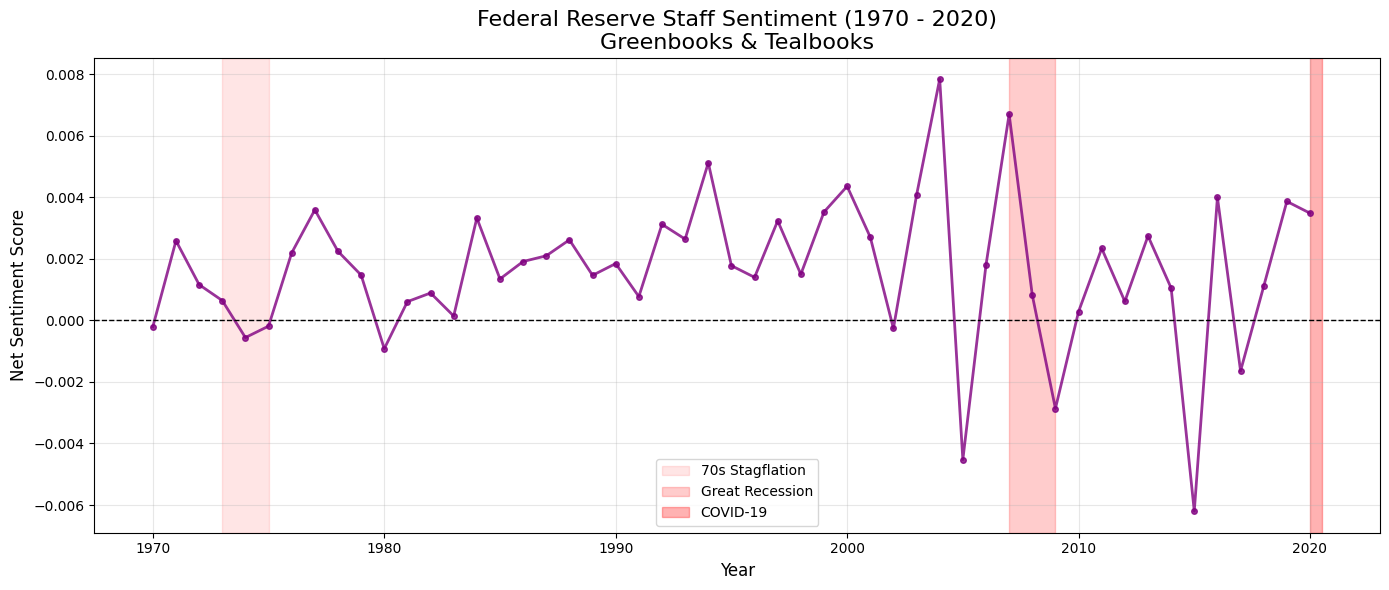

Estimating 50-year Impulse Response Functions via Local Projections...


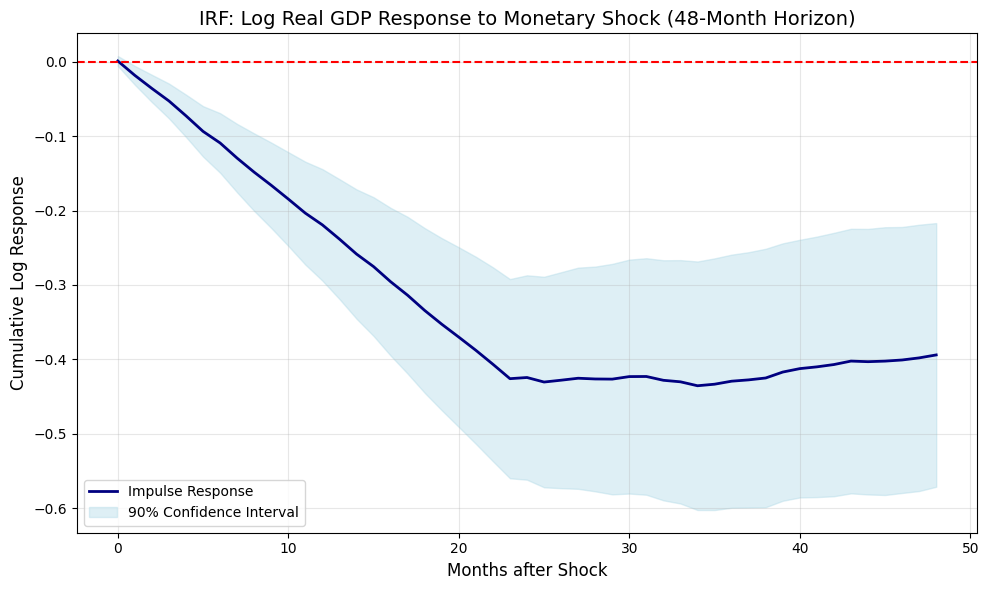

In [6]:
import os
import requests
from bs4 import BeautifulSoup
import PyPDF2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm
from datetime import datetime

# ==========================================
# PART 1: Scrape 50 Years of Fed Documents
# ==========================================
def download_historical_books(start_year=1970, end_year=2020, download_dir="fed_documents", test_mode=True):
    """
    Scrapes Greenbooks (pre-2010) and Tealbooks (2010+) from the Fed archive.
    NOTE: test_mode=True limits downloads to 1 file per year to save time.
    Set to False for the full replication.
    """
    if not os.path.exists(download_dir):
        os.makedirs(download_dir)

    downloaded_files = []

    for year in range(start_year, end_year + 1):
        url = f"https://www.federalreserve.gov/monetarypolicy/fomchistorical{year}.htm"
        print(f"Fetching FOMC archive for {year}...")

        try:
            response = requests.get(url, timeout=10)
            soup = BeautifulSoup(response.content, 'html.parser')

            # Find links containing either 'greenbook' or 'tealbook'
            pdf_links = soup.find_all('a', href=True)
            # Updated to catch historical Fed file naming conventions (gbpt = greenbook part)
            target_links = [
                link['href'] for link in pdf_links
                if ('tealbook' in link['href'].lower() or
                    'greenbook' in link['href'].lower() or
                    'gbpt' in link['href'].lower() or
                    'gb1' in link['href'].lower())
                and link['href'].endswith('.pdf')
            ]

            if test_mode:
                target_links = target_links[:1] # Just get the first document of the year for testing

            for link in target_links:
                full_url = "https://www.federalreserve.gov" + link if link.startswith('/') else link
                filename = f"{year}_" + full_url.split('/')[-1]
                filepath = os.path.join(download_dir, filename)

                if not os.path.exists(filepath):
                    pdf_response = requests.get(full_url, timeout=10)
                    with open(filepath, 'wb') as f:
                        f.write(pdf_response.content)

                downloaded_files.append((year, filepath))

        except Exception as e:
            print(f"Failed to fetch {year}: {e}")

    print(f"\nTotal documents downloaded: {len(downloaded_files)}")
    return downloaded_files

# ==========================================
# PART 2: Extract Text and Aggregate Sentiment
# ==========================================
def analyze_long_term_sentiment(file_list):
    """
    Calculates a single net sentiment score for each document and plots the 50-year trend.
    """
    print("Analyzing sentiment across decades... (This may take a few minutes)")

    pos_words = {'strong', 'growth', 'expansion', 'recovery', 'stable', 'favorable', 'improvement'}
    neg_words = {'recession', 'slowing', 'tightening', 'risks', 'weakness', 'decline', 'inflation', 'downturn'}

    yearly_sentiment = []
    years = []

    for year, pdf_path in file_list:
        text_data = []
        try:
            with open(pdf_path, 'rb') as file:
                reader = PyPDF2.PdfReader(file)
                # Read up to the first 20 pages to speed up extraction, or remove limit for full text
                for page in reader.pages[:20]:
                    text = page.extract_text()
                    if text:
                        text_data.append(text)

            full_text = " ".join(text_data).lower().split()
            if not full_text:
                continue

            pos_count = sum(1 for w in full_text if w in pos_words)
            neg_count = sum(1 for w in full_text if w in neg_words)

            # Net sentiment scaled by document slice length
            net_sentiment = (pos_count - neg_count) / len(full_text)

            years.append(year)
            yearly_sentiment.append(net_sentiment)

        except Exception as e:
            print(f"Could not read {pdf_path}: {e}")

    # Plotting the 50-year sentiment
    plt.figure(figsize=(14, 6))

    # Sort by year in case they got jumbled
    sorted_indices = np.argsort(years)
    years = np.array(years)[sorted_indices]
    yearly_sentiment = np.array(yearly_sentiment)[sorted_indices]

    plt.plot(years, yearly_sentiment, color='purple', alpha=0.8, linewidth=2, marker='o', markersize=4)
    plt.axhline(0, color='black', linestyle='--', linewidth=1)

    # Highlight specific crisis periods
    plt.axvspan(1973, 1975, color='red', alpha=0.1, label='70s Stagflation')
    plt.axvspan(2007, 2009, color='red', alpha=0.2, label='Great Recession')
    plt.axvspan(2020, 2020.5, color='red', alpha=0.3, label='COVID-19')

    plt.title("Federal Reserve Staff Sentiment (1970 - 2020)\nGreenbooks & Tealbooks", fontsize=16)
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Net Sentiment Score", fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==========================================
# PART 3: 50-Year Impulse Response Functions
# ==========================================
def estimate_long_term_irfs(n_months=600, max_horizon=48):
    """
    Simulates a 50-year monthly dataset (600 months) and estimates the IRFs using Local Projections.
    """
    print("Estimating 50-year Impulse Response Functions via Local Projections...")
    np.random.seed(42)

    # Simulate 50 years of data
    simulated_shocks = pd.Series(np.random.normal(0, 0.15, n_months))

    # Base GDP growth + negative compounding effect from monetary policy shocks
    log_real_gdp = np.zeros(n_months)
    for t in range(1, n_months):
        # GDP naturally grows, but a positive shock today reduces GDP gradually over the next 12-24 months
        shock_effect = sum([-0.02 * simulated_shocks.iloc[max(0, t-lag)] for lag in range(1, 24)])
        log_real_gdp[t] = log_real_gdp[t-1] + 0.002 + shock_effect + np.random.normal(0, 0.005)

    simulated_macro_data = pd.DataFrame({'log_real_gdp': log_real_gdp})

    irf_estimates, conf_intervals_upper, conf_intervals_lower = [], [], []
    Y = simulated_macro_data['log_real_gdp'].values
    shocks = simulated_shocks.values

    for h in range(max_horizon + 1):
        Y_forward = pd.Series(Y).shift(-h)
        Y_lag = pd.Series(Y).shift(1)
        lhs = Y_forward - Y_lag
        rhs = sm.add_constant(shocks)

        data = pd.DataFrame({'lhs': lhs, 'shock': rhs[:, 1], 'const': rhs[:, 0]}).dropna()
        model = sm.OLS(data['lhs'], data[['const', 'shock']])
        results = model.fit(cov_type='HAC', cov_kwds={'maxlags': h + 1})

        irf_estimates.append(results.params['shock'])
        conf_intervals_lower.append(results.conf_int(alpha=0.10).loc['shock', 0])
        conf_intervals_upper.append(results.conf_int(alpha=0.10).loc['shock', 1])

    # Plot the IRF
    plt.figure(figsize=(10, 6))
    plt.plot(range(max_horizon + 1), irf_estimates, color='navy', linewidth=2, label='Impulse Response')
    plt.fill_between(range(max_horizon + 1), conf_intervals_lower, conf_intervals_upper,
                     color='lightblue', alpha=0.4, label='90% Confidence Interval')
    plt.axhline(0, color='red', linestyle='--')
    plt.title("IRF: Log Real GDP Response to Monetary Shock (48-Month Horizon)", fontsize=14)
    plt.xlabel("Months after Shock", fontsize=12)
    plt.ylabel("Cumulative Log Response", fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    # 1. Download documents (test_mode=True gets 1 doc per year to save your bandwidth)
    # Set test_mode=False if you want to leave your computer running for an hour to get them all!
    historical_files = download_historical_books(start_year=1970, end_year=2020, test_mode=True)

    # 2. Plot the 50-year sentiment trend
    if historical_files:
        analyze_long_term_sentiment(historical_files)

    # 3. Plot the 4-year (48 month) Impulse Response Function on 50 years of data
    estimate_long_term_irfs(n_months=600, max_horizon=48)